In [1]:
# ## 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from collections import namedtuple
import time
from tqdm.auto import tqdm # Import tqdm for progress bars

def do_ple_scan(lines = 1, in_range = None, frequency=None, resolution=None, channel = None):
    """
    fine_scan_range = (
            ple_gui.fit_result[1].best_values['center']
            - ple_gui.fit_result[1].best_values['sigma'] * 3,
            ple_gui.fit_result[1].best_values['center']
            + ple_gui.fit_result[1].best_values['sigma']  * 3
        )
    """
    if channel is not None:
        ple_gui._mw.channel_comboBox.setCurrentText(channel) ## MAY BE MISTAKEN
        # ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    #laser_scanner_logic.scan_ranges["a"]
    if in_range is None:
        ple_gui._mw.actionFull_range.triggered.emit()
    else:
        ple_gui.sigScanSettingsChanged.emit(
            {'range': {ple_gui.scan_axis: in_range}}
        )
    ple_gui._mw.number_of_repeats_SpinBox.setValue(lines)
    ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()
    time.sleep(0.5)
    ple_gui._mw.actionToggle_scan.setChecked(True)
    ple_gui.toggle_scan()
    while laser_scanner_logic.module_state()=='locked':
            time.sleep(0.5)
    time.sleep(0.2)
    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
    time.sleep(0.2)
    #ple_gui._accumulated_data.mean(axis=0)
    #print(f"Rsquared {ple_gui.fit_result[1].rsquared}")
    #ple_gui.fit_result[1].params["center"].value
    return ple_gui.fit_result[1]

def save_ple(tag, poi_name=None, folder_name = None):
        if folder_name:
            ple_gui._save_folderpath = folder_name
            ple_gui.save_path_widget.currPathLabel.setText(ple_gui._save_folderpath)
        ple_gui.save_path_widget.saveTagLineEdit.setText(
            f"{tag}"
            )
        ple_gui._mw.actionSave.triggered.emit()
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

In [4]:
vector_magnet

<qudi.hardware.vector_magnet.ami_vector_magnet.Magnet3D(0x1f24c0495e0) at 0x000001F26CA5D040>

In [ ]:
vector_magnet.get_field()

In [35]:
vector_magnet.ramp(field_target= [0.0, 0.6, 0])

In [13]:
B_amplitude = 0.5  # Tesla

# Define the angular resolution of the sweep
theta_steps = 7  # Number of steps from 0 to 90 deg
phi_steps = 12  # Number of steps from 0 to 90 deg

# Create the grid of angles for the first octant (all components positive)
# theta: 0 to pi/2
# phi: 0 to p
thetas = np.linspace(np.pi/2, np.pi/2 - np.pi/10, theta_steps)
phis = np.linspace(0, np.pi/4, phi_steps)

all_field_targets = []

# Iterate through each point on the spherical grid
for phi in phis:
    for theta in thetas:
        # a. Convert spherical to Cartesian coordinates
        By = B_amplitude * np.sin(theta) * np.cos(phi)
        Bx = B_amplitude * np.sin(theta) * np.sin(phi)
        Bz = B_amplitude * np.cos(theta)
        field_target = [Bx, By, Bz]
        all_field_targets.append(field_target)

print(f"Generated {len(all_field_targets)} points in the first octant.")

# ## 3. Prepare Data for Plotting
# Convert the list of points into a NumPy array for easier slicing
points_array = np.array(all_field_targets)


Generated 84 points in the first octant.


Generating 3D plot...


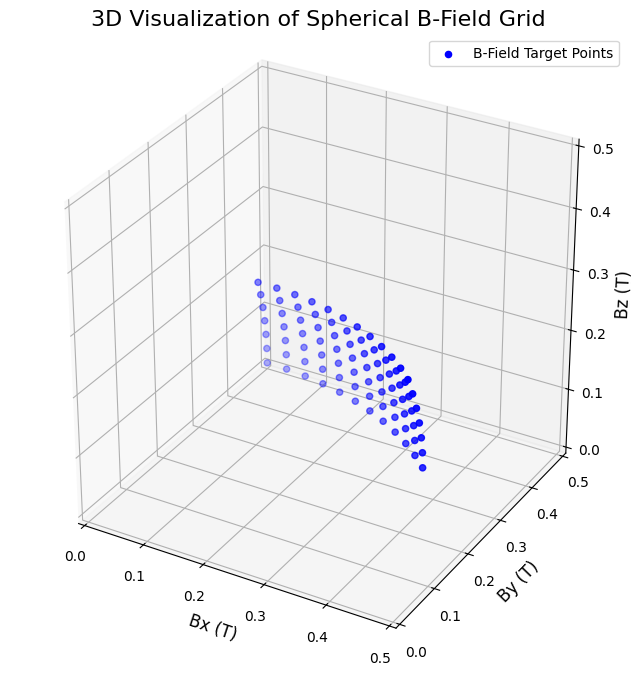

Plot displayed.


In [16]:
points_array = np.array(all_field_targets)

# Extract X, Y, and Z coordinates
x_coords = points_array[:, 0]
y_coords = points_array[:, 1]
z_coords = points_array[:, 2]

# ## 4. Create the 3D Plot
print("Generating 3D plot...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(x_coords, y_coords, z_coords, c='b', marker='o', label='B-Field Target Points')

# Add labels and a title for clarity
ax.set_xlabel('Bx (T)', fontsize=12)
ax.set_ylabel('By (T)', fontsize=12)
ax.set_zlabel('Bz (T)', fontsize=12)
ax.set_title('3D Visualization of Spherical B-Field Grid', fontsize=16)

# Set the axis limits to be equal to ensure a spherical appearance
ax.set_xlim([0, B_amplitude])
ax.set_ylim([0, B_amplitude])
ax.set_zlim([0, B_amplitude])
ax.set_aspect('equal') # This is crucial for a correct aspect ratio

# Add a legend
ax.legend()

# Show the plot
plt.show()
print("Plot displayed.")

In [14]:
vector_magnet.ramp(field_target= [0.1,0.0,0.1])

In [2]:
ple_gui._fit_averaged = False

In [17]:
folder = r'Z:\Vlad\heavyIV\202-2-ARed\CPW\somewhere\B_sweep_4_perp'

In [ ]:
print("Waiting for initial vector magnet ramping to complete...")
while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
    print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
    time.sleep(30)
print("✅ Vector magnet is ready.")

ple_splitting = []

# --- Main Loop with tqdm Progress Bar ---
# Use tqdm to create a progress bar for the loop over field targets
for field_target in tqdm(all_field_targets, desc="Field Target Progress"):
    print(f"\n--- Starting new measurement for target: {field_target} ---")
    
    # --- Ramping the Field ---
    print(f"Ramping to field target: {field_target} T")
    vector_magnet.ramp(field_target=field_target)
    
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        
        time.sleep(2)
    
    
    # --- Performing PLE Scan ---
    
    fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
    

    # --- Waiting for Laser Scanner ---
    while laser_scanner_logic.module_state() == 'locked':
        
        time.sleep(0.5)
    

    # --- Calculating Splitting ---
    delta = fit.params['center_2'].value - fit.params['center_1'].value
    
    ple_splitting.append(delta)

    # --- Saving Data ---
    tag = f"target_{field_target}_T"
    
    save_ple(tag=tag,
             poi_name=None,
             folder_name=folder)
    

print("\n--- All measurements complete! ---")
print(f"Final PLE Splitting Values (MHz): {ple_splitting}")

Waiting for initial vector magnet ramping to complete...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: [2, 1, 2] - Waiting...
Current ramping state: 

Field Target Progress:   0%|          | 0/84 [00:00<?, ?it/s]


--- Starting new measurement for target: [0.0, 0.5, 3.061616997868383e-17] ---
Ramping to field target: [0.0, 0.5, 3.061616997868383e-17] T

--- Starting new measurement for target: [0.0, 0.4993147673772869, 0.026167978121471983] ---
Ramping to field target: [0.0, 0.4993147673772869, 0.026167978121471983] T

--- Starting new measurement for target: [0.0, 0.49726094768413664, 0.05226423163382673] ---
Ramping to field target: [0.0, 0.49726094768413664, 0.05226423163382673] T

--- Starting new measurement for target: [0.0, 0.4938441702975689, 0.07821723252011546] ---
Ramping to field target: [0.0, 0.4938441702975689, 0.07821723252011546] T

--- Starting new measurement for target: [0.0, 0.4890738003669028, 0.10395584540887973] ---
Ramping to field target: [0.0, 0.4890738003669028, 0.10395584540887973] T

--- Starting new measurement for target: [0.0, 0.48296291314453416, 0.12940952255126037] ---
Ramping to field target: [0.0, 0.48296291314453416, 0.12940952255126037] T

--- Starting new 

: 